In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import huracanpy
from cartopy.crs import EqualEarth
from huracanpy.plot import fancyline
import seaborn as sns
from tc_helpers import *

In [2]:
tracks = load_syclops()

10kmCoMorph TC tracks loaded successfully
10kmGAL TC tracks loaded successfully
5kmCoMorph TC tracks loaded successfully
5kmRAL TC tracks loaded successfully


/home/users/l_grant/.conda/envs/hk26_env/lib/python3.14/site-packages/huracanpy/_data/ibtracs.py:119: UserWarning: This offline function loads a light version of IBTrACS which is embedded within the package, based on a file produced manually by the developers.
 It was last updated on the 15th Nov 2024, based on the IBTrACS file at that date.
 It contains only data from 1980 up to the last year with no provisional tracks. All spur tracks were removed. Only 6-hourly time steps were kept.
  warnings.warn(


JTWC tracks loaded successfully


In [3]:
for name,ds in tracks.items():
    ds_tmp = compute_intensification_rate(ds, var='sfcwind_max', timedelta=6)
    tracks[name] = compute_intensification_rate(ds_tmp, var='psl_min', timedelta=6)

24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr


In [4]:
cm5 = tracks['5kmCoMorph']
test_track = cm5.where(cm5.track_id == 139, drop=True)
test_track.sfcwind_max.max()

<xarray.DataArray 'sfcwind_max' ()> Size: 8B
array(129.69759528)

Peak surface wind speed: <xarray.DataArray 'sfcwind_max' ()> Size: 8B
array(129.69759528) knots


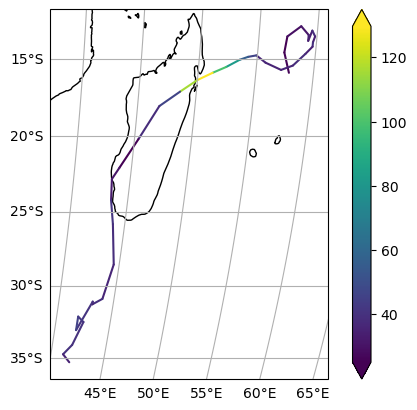

In [5]:
# Set up a figure with a cartopy projection
ax = plt.axes(projection=EqualEarth())

# Show surface wind speed with a colourscale
lc = fancyline(
    test_track.lon,
    test_track.lat,
    test_track.sfcwind_max,
    vmax=test_track.sfcwind_max.max(),
    vmin=25,
    ax=ax,
)

plt.colorbar(lc, extend="both")
ax.coastlines()
ax.gridlines(draw_labels=["left", "bottom"])
print(f'Peak surface wind speed: {test_track.sfcwind_max.max()} knots')

<Axes: xlabel='time_from_wind_max', ylabel='Min SLP [hPa]'>

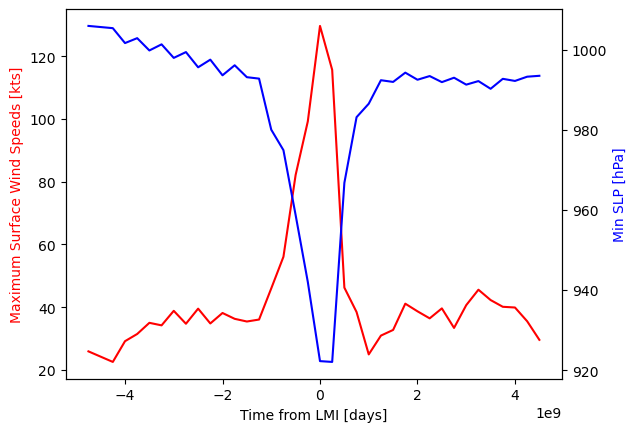

In [6]:
# Time series of this intense storm: 
# Compute times from extremum
test_track["time_from_wind_max"] = test_track.hrcn.get_time_from_apex(
    intensity_var_name="sfcwind_max", stat="max") / (24*3600)

test_track['time_from_slp_min'] = test_track.hrcn.get_time_from_apex(
    intensity_var_name="psl_min", stat="min") / (24*3600)

# Plot with seaborn
fig, ax = plt.subplots(1, sharex=True)
ax.set_ylabel('Maximum Surface Wind Speeds [kts]', color='r')
ax.set_xlabel('Time from LMI [days]')
ax2 = ax.twinx()
ax2.set_ylabel('Min SLP [hPa]', color='b')
# Wind lifecycle
sns.lineplot(data=test_track, x="time_from_wind_max", y="sfcwind_max", ax=ax, color= 'r')
sns.lineplot(data=test_track, x='time_from_wind_max', y='psl_min', ax=ax2, color='b')

In [8]:
cm5_si = huracanpy.trackswhere(cm5, cm5.track_id, lambda x:(x.lon.min()>20) & (x.lon.max() < 135))
cm5_si.track_id.hrcn.nunique()

30